In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("WARNING: GPU is not available.")
    print("For this research model, Kaggle GPU is strongly recommended.")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [3]:
!pip -q install timm scikit-learn seaborn

# Install/Import Required Libraries #  

In [4]:
import os
import json
import time
import math
import copy
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms

import timm

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("timm:", timm.__version__)

Device: cuda
Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
timm: 1.0.26


In [1]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

print("Random seed:", SEED)

Random seed: 42


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

IMAGE_SIZE = 224

BATCH_SIZE = 16          # Reduce to 8 if GPU memory is insufficient
NUM_WORKERS = 2

EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

PATIENCE = 4

# CNN backbone
CNN_BACKBONE = "resnet50"

# Transformer backbone
SWIN_BACKBONE = "swin_tiny_patch4_window7_224"

# Feature dimension after projection
FUSION_DIM = 192

DROPOUT = 0.30

# Mixed precision
USE_AMP = torch.cuda.is_available()

# Number of classes
NUM_CLASSES = None

# Save directory
OUTPUT_DIR = Path("/kaggle/working/plant_disease_stcfi")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: /kaggle/working/plant_disease_stcfi


In [3]:
CNN_BACKBONE = "resnet101"

In [6]:
INPUT_DIR = Path("/kaggle/input")

print("Datasets available in Kaggle:")
for p in INPUT_DIR.iterdir():
    print(" -", p)

Datasets available in Kaggle:
 - /kaggle/input/datasets


# Locate PlantVillage and PlantDoc # 

In [7]:
for p in INPUT_DIR.iterdir():
    print("\nDATASET:", p)
    if p.is_dir():
        try:
            for child in list(p.iterdir())[:20]:
                print("   ", child.name)
        except Exception:
            pass


DATASET: /kaggle/input/datasets
    abdallahalidev
    andresmgs


In [8]:
# ============================================================
# SET DATASET PATHS AFTER INSPECTING CELL 6
# ============================================================

PLANTVILLAGE_ROOT = Path("/kaggle/input/datasets/abdallahalidev/plantvillage-dataset")

# Change this if your PlantDoc folder has a different name.
PLANTDOC_ROOT = Path("/kaggle/input/datasets/andresmgs/plantdec")

print("PlantVillage:", PLANTVILLAGE_ROOT)
print("Exists:", PLANTVILLAGE_ROOT.exists())

print("PlantDoc:", PLANTDOC_ROOT)
print("Exists:", PLANTDOC_ROOT.exists())

PlantVillage: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset
Exists: True
PlantDoc: /kaggle/input/datasets/andresmgs/plantdec
Exists: True


# Inspect PlantVillage # 

In [9]:
def list_directory_structure(root, depth=2):
    root = Path(root)
    
    if not root.exists():
        print("Path does not exist:", root)
        return
    
    print(f"\nStructure of: {root}")
    
    for p in sorted(root.rglob("*")):
        relative = p.relative_to(root)
        
        if len(relative.parts) <= depth:
            prefix = "  " * (len(relative.parts)-1)
            print(prefix + ("📁 " if p.is_dir() else "📄 ") + p.name)

list_directory_structure(PLANTVILLAGE_ROOT, depth=2)


Structure of: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset
📁 color
  📁 Apple___Apple_scab
  📁 Apple___Black_rot
  📁 Apple___Cedar_apple_rust
  📁 Apple___healthy
  📁 Blueberry___healthy
  📁 Cherry_(including_sour)___Powdery_mildew
  📁 Cherry_(including_sour)___healthy
  📁 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
  📁 Corn_(maize)___Common_rust_
  📁 Corn_(maize)___Northern_Leaf_Blight
  📁 Corn_(maize)___healthy
  📁 Grape___Black_rot
  📁 Grape___Esca_(Black_Measles)
  📁 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  📁 Grape___healthy
  📁 Orange___Haunglongbing_(Citrus_greening)
  📁 Peach___Bacterial_spot
  📁 Peach___healthy
  📁 Pepper,_bell___Bacterial_spot
  📁 Pepper,_bell___healthy
  📁 Potato___Early_blight
  📁 Potato___Late_blight
  📁 Potato___healthy
  📁 Raspberry___healthy
  📁 Soybean___healthy
  📁 Squash___Powdery_mildew
  📁 Strawberry___Leaf_scorch
  📁 Strawberry___healthy
  📁 Tomato___Bacterial_spot
  📁 Tomato___Early_blight
  📁 Tomato___Late_blight
  📁 Tomat

# Collect PlantVillage Images # 

In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_images_from_class_folders(root):
    rows = []
    
    root = Path(root)
    
    for image_path in root.rglob("*"):
        if not image_path.is_file():
            continue
        
        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        
        # immediate parent directory = class
        class_name = image_path.parent.name
        
        rows.append({
            "filepath": str(image_path),
            "class_name": class_name
        })
    
    return pd.DataFrame(rows)


plantvillage_df = collect_images_from_class_folders(
    PLANTVILLAGE_ROOT
)

print("Total images:", len(plantvillage_df))
print("Classes:", plantvillage_df["class_name"].nunique())

display(
    plantvillage_df["class_name"]
    .value_counts()
    .sort_index()
    .to_frame("count")
)

Total images: 325832
Classes: 38


,count
class_name,
Apple___Apple_scab,3780
Apple___Black_rot,3726
Apple___Cedar_apple_rust,1650
Apple___healthy,9870
Blueberry___healthy,9012
Cherry_(including_sour)___Powdery_mildew,6312
Cherry_(including_sour)___healthy,5124
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,3078
Corn_(maize)___Common_rust_,7152


# Visualize Sample Images # 

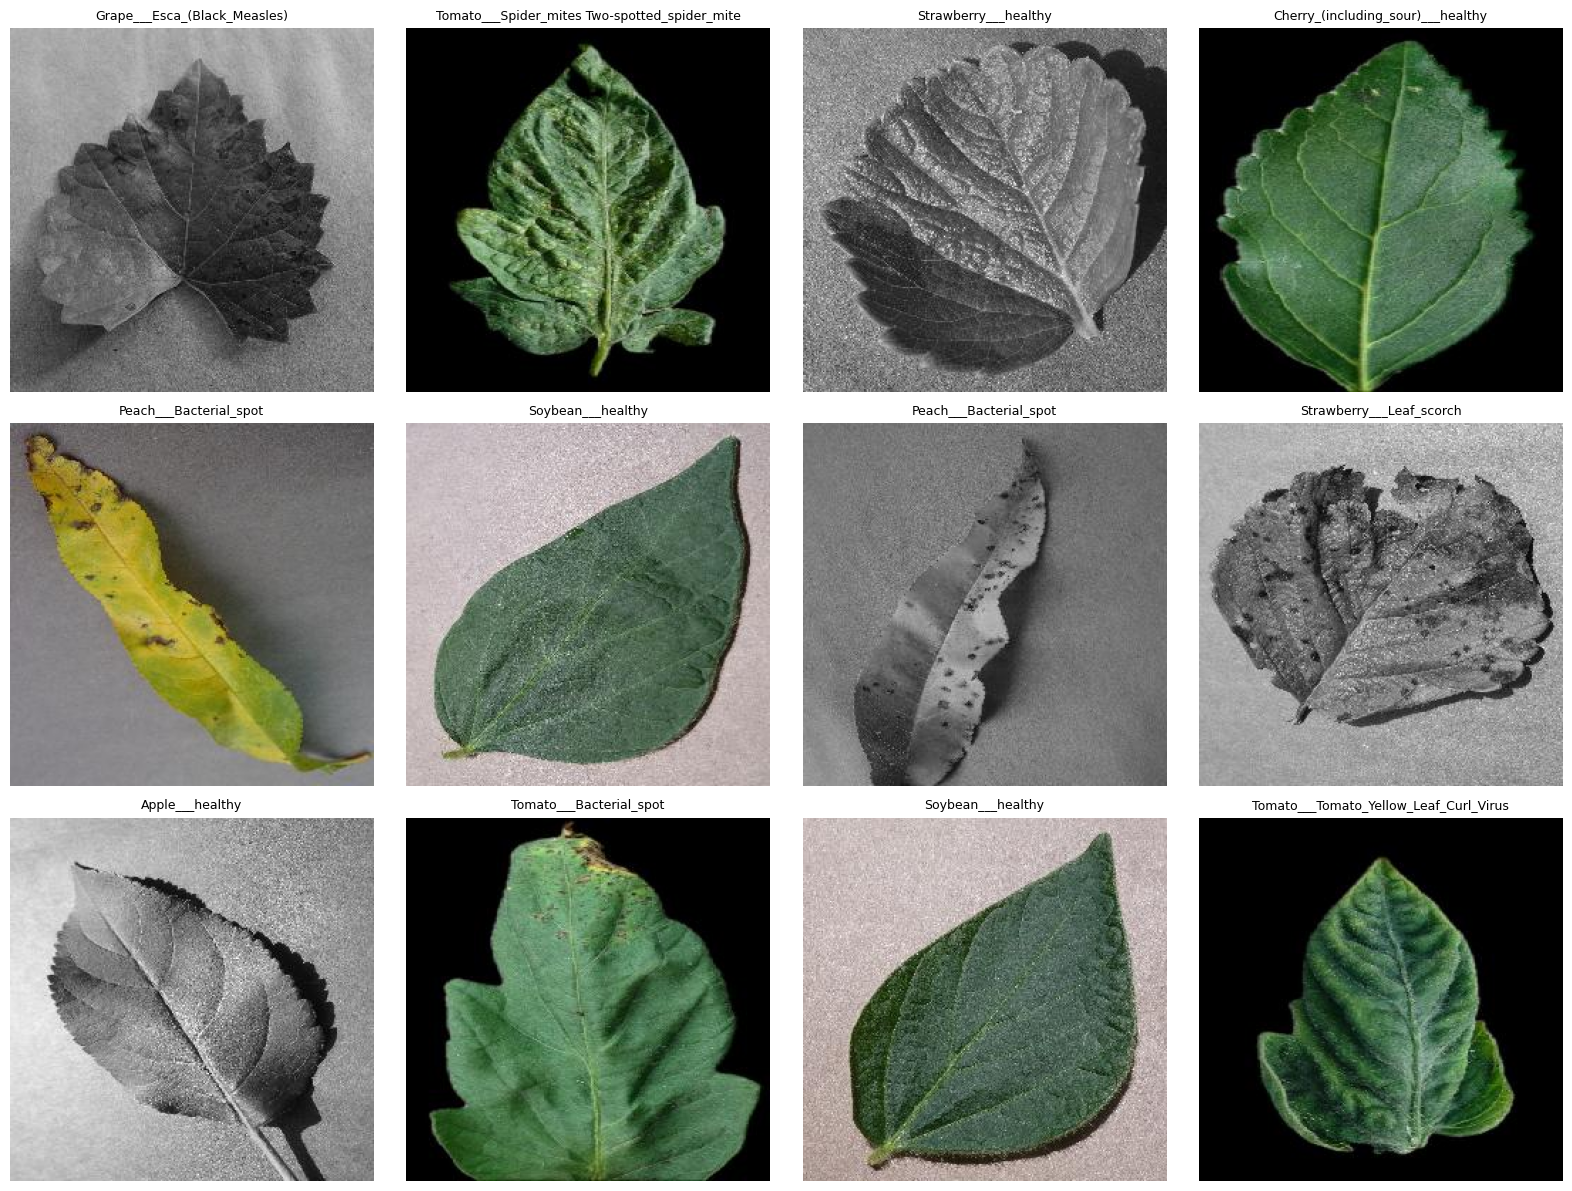

In [11]:
def show_samples(df, n=12):
    sample_df = df.sample(
        min(n, len(df)),
        random_state=SEED
    )
    
    cols = 4
    rows = math.ceil(len(sample_df) / cols)
    
    plt.figure(figsize=(16, 4 * rows))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["filepath"]).convert("RGB")
        
        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img)
        ax.set_title(row["class_name"], fontsize=9)
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()


show_samples(plantvillage_df, 12)

# Stratified Train/Validation/Test Split # 

In [12]:
train_df, temp_df = train_test_split(
    plantvillage_df,
    test_size=0.30,
    stratify=plantvillage_df["class_name"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 228082
Validation: 48875
Test: 48875


In [13]:
print("\nTrain classes:", train_df["class_name"].nunique())
print("Validation classes:", val_df["class_name"].nunique())
print("Test classes:", test_df["class_name"].nunique())


Train classes: 38
Validation classes: 38
Test classes: 38


#  Label Encoding # 

In [14]:
class_names = sorted(
    train_df["class_name"].unique()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

idx_to_class = {
    idx: name
    for name, idx in class_to_idx.items()
}

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

for idx, name in idx_to_class.items():
    print(idx, "->", name)

Number of classes: 38
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy
5 -> Cherry_(including_sour)___Powdery_mildew
6 -> Cherry_(including_sour)___healthy
7 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 -> Corn_(maize)___Common_rust_
9 -> Corn_(maize)___Northern_Leaf_Blight
10 -> Corn_(maize)___healthy
11 -> Grape___Black_rot
12 -> Grape___Esca_(Black_Measles)
13 -> Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 -> Grape___healthy
15 -> Orange___Haunglongbing_(Citrus_greening)
16 -> Peach___Bacterial_spot
17 -> Peach___healthy
18 -> Pepper,_bell___Bacterial_spot
19 -> Pepper,_bell___healthy
20 -> Potato___Early_blight
21 -> Potato___Late_blight
22 -> Potato___healthy
23 -> Raspberry___healthy
24 -> Soybean___healthy
25 -> Squash___Powdery_mildew
26 -> Strawberry___Leaf_scorch
27 -> Strawberry___healthy
28 -> Tomato___Bacterial_spot
29 -> Tomato___Early_blight
30 -> Tomato___Late_blight
31 -> Tomato___Le

In [20]:
with open(
    OUTPUT_DIR / "class_mapping.json",
    "w"
) as f:
    json.dump(
        {
            "class_to_idx": class_to_idx,
            "idx_to_class": idx_to_class
        },
        f,
        indent=4
    )

# Robust Training Augmentation # 

We want to expose the model to:

1. illumination changes
2. blur
3. small rotations
4. scale changes
5. partial occlusion
6. image noise

In [22]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    
    transforms.RandomVerticalFlip(
        p=0.15
    ),
    
    transforms.RandomRotation(
        degrees=20
    ),
    
    transforms.ColorJitter(
        brightness=0.30,
        contrast=0.30,
        saturation=0.25,
        hue=0.05
    ),
    
    transforms.RandomApply(
        [
            transforms.GaussianBlur(
                kernel_size=5,
                sigma=(0.1, 2.0)
            )
        ],
        p=0.20
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    ),
    
    transforms.RandomErasing(
        p=0.20,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3),
        value="random"
    )
])


eval_transform = transforms.Compose([
    
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    
    transforms.ToTensor(),
    
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

# Dataset Class # 

In [23]:
class PlantDiseaseDataset(Dataset):
    
    def __init__(
        self,
        dataframe,
        class_to_idx,
        transform=None
    ):
        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        
        row = self.df.iloc[idx]
        
        image_path = row["filepath"]
        class_name = row["class_name"]
        
        try:
            image = Image.open(
                image_path
            ).convert("RGB")
        except Exception as e:
            print(
                f"Error loading image: {image_path}"
            )
            raise e
        
        if self.transform:
            image = self.transform(image)
        
        label = self.class_to_idx[class_name]
        
        return image, label

# Create Dataset # 

In [24]:
train_dataset = PlantDiseaseDataset(
    train_df,
    class_to_idx,
    train_transform
)

val_dataset = PlantDiseaseDataset(
    val_df,
    class_to_idx,
    eval_transform
)

test_dataset = PlantDiseaseDataset(
    test_df,
    class_to_idx,
    eval_transform
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

228082 48875 48875


# Handle Class Imbalance # 

In [25]:
train_labels = [
    class_to_idx[c]
    for c in train_df["class_name"]
]

class_counts = Counter(train_labels)

class_weights = {
    cls: len(train_labels) / count
    for cls, count in class_counts.items()
}

sample_weights = [
    class_weights[label]
    for label in train_labels
]

sample_weights = torch.DoubleTensor(
    sample_weights
)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

# DataLoaders # 

In [28]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 14256
Validation batches: 3055
Test batches: 3055


 # Test One Batch # 

In [29]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

images = images.to(DEVICE)

print("Moved batch to:", images.device)

Image batch shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([25,  4,  9, 10,  4,  7, 37, 31, 13, 26])
Moved batch to: cuda:0


# ST-CFI Inspired Model # 

This is the main architecture.

The published ST-CFI uses a ResNet stream + Swin Transformer stream, with feature interaction at multiple stages.

Our implementation additionally introduces:

Adaptive Feature Selection
and
Enhanced Multi-Scale Fusion

In [37]:
class AdaptiveFeatureSelection(nn.Module):
    """
    Learns the importance of each feature channel.
    Input:
        [B, C, H, W]
    Output:
        selected features + channel attention weights
    """

    def __init__(self, dim, reduction=4):
        super().__init__()

        hidden_dim = max(dim // reduction, 16)

        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Global average pooling
        pooled = F.adaptive_avg_pool2d(
            x, 1
        ).flatten(1)

        weights = self.mlp(pooled)

        weights = weights.unsqueeze(-1).unsqueeze(-1)

        selected = x * weights

        return selected, weights


class STCFIInteraction(nn.Module):
    """
    CNN + Swin feature interaction block.

    IMPORTANT:
    Both inputs must be NCHW:
        [B, C, H, W]
    """

    def __init__(
        self,
        cnn_dim,
        swin_dim,
        fusion_dim
    ):
        super().__init__()

        self.cnn_proj = nn.Sequential(
            nn.Conv2d(
                cnn_dim,
                fusion_dim,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(fusion_dim),
            nn.ReLU(inplace=True)
        )

        self.swin_proj = nn.Sequential(
            nn.Conv2d(
                swin_dim,
                fusion_dim,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(fusion_dim),
            nn.ReLU(inplace=True)
        )

        self.interaction = nn.Sequential(
            nn.Conv2d(
                fusion_dim * 2,
                fusion_dim,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(fusion_dim),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                fusion_dim,
                fusion_dim,
                kernel_size=1,
                bias=False
            ),
            nn.BatchNorm2d(fusion_dim),
            nn.ReLU(inplace=True)
        )

        self.selector = AdaptiveFeatureSelection(
            fusion_dim
        )

        # Learnable CNN / Swin fusion weights
        self.alpha = nn.Parameter(
            torch.tensor(0.5)
        )

        self.beta = nn.Parameter(
            torch.tensor(0.5)
        )

    def forward(
        self,
        cnn_feature,
        swin_feature
    ):

        # -------------------------------------------------
        # Convert NHWC -> NCHW if required
        # -------------------------------------------------

        if cnn_feature.ndim != 4:
            raise RuntimeError(
                f"Unexpected CNN feature shape: "
                f"{cnn_feature.shape}"
            )

        if swin_feature.ndim != 4:
            raise RuntimeError(
                f"Unexpected Swin feature shape: "
                f"{swin_feature.shape}"
            )

        # Swin from timm may return:
        # [B, H, W, C]
        #
        # Convert to:
        # [B, C, H, W]

        if (
            swin_feature.shape[-1]
            != swin_feature.shape[1]
        ):
            swin_feature = swin_feature.permute(
                0, 3, 1, 2
            ).contiguous()

        # CNN should normally already be NCHW.
        # However, this safety check handles
        # channels-last CNN output too.

        if (
            cnn_feature.shape[-1]
            != cnn_feature.shape[1]
            and cnn_feature.shape[1]
            not in [3, 16, 32, 64, 128, 256, 512, 1024, 2048]
        ):
            cnn_feature = cnn_feature.permute(
                0, 3, 1, 2
            ).contiguous()

        # -------------------------------------------------
        # Project features into common dimension
        # -------------------------------------------------

        cnn_feature = self.cnn_proj(
            cnn_feature
        )

        swin_feature = self.swin_proj(
            swin_feature
        )

        # -------------------------------------------------
        # Spatial alignment
        # -------------------------------------------------

        if (
            cnn_feature.shape[-2:]
            != swin_feature.shape[-2:]
        ):
            swin_feature = F.interpolate(
                swin_feature,
                size=cnn_feature.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        # -------------------------------------------------
        # Learnable weighted fusion
        # -------------------------------------------------

        weights = torch.softmax(
            torch.stack([
                self.alpha,
                self.beta
            ]),
            dim=0
        )

        alpha = weights[0]
        beta = weights[1]

        weighted_features = (
            alpha * cnn_feature
            +
            beta * swin_feature
        )

        # -------------------------------------------------
        # Cross-feature interaction
        # -------------------------------------------------

        interaction_input = torch.cat(
            [
                cnn_feature,
                swin_feature
            ],
            dim=1
        )

        interaction_features = self.interaction(
            interaction_input
        )

        fused = (
            weighted_features
            +
            interaction_features
        )

        # -------------------------------------------------
        # Adaptive feature selection
        # -------------------------------------------------

        selected, selection_weights = (
            self.selector(fused)
        )

        # -------------------------------------------------
        # Residual connection
        # -------------------------------------------------

        output = selected + weighted_features

        return (
            output,
            selection_weights
        )

# Complete ST-CFI Enhanced Network # 

In [40]:
class STCFIEnhanced(nn.Module):

    def __init__(
        self,
        num_classes,
        cnn_name=CNN_BACKBONE,
        swin_name=SWIN_BACKBONE,
        fusion_dim=FUSION_DIM,
        dropout=DROPOUT,
        pretrained=True
    ):

        super().__init__()

        print("Creating CNN:", cnn_name)
        print("Creating Swin:", swin_name)

        # =====================================================
        # CNN BRANCH
        # =====================================================

        try:

            self.cnn = timm.create_model(
                cnn_name,
                pretrained=pretrained,
                features_only=True,
                out_indices=(1, 2, 3, 4)
            )

        except Exception as e:

            print(
                "Could not load pretrained CNN weights."
            )

            print(
                "Using random initialization."
            )

            self.cnn = timm.create_model(
                cnn_name,
                pretrained=False,
                features_only=True,
                out_indices=(1, 2, 3, 4)
            )

        # =====================================================
        # SWIN BRANCH
        # =====================================================

        try:

            self.swin = timm.create_model(
                swin_name,
                pretrained=pretrained,
                features_only=True,
                out_indices=(0, 1, 2, 3)
            )

        except Exception as e:

            print(
                "Could not load pretrained Swin weights."
            )

            print(
                "Using random initialization."
            )

            self.swin = timm.create_model(
                swin_name,
                pretrained=False,
                features_only=True,
                out_indices=(0, 1, 2, 3)
            )

        # =====================================================
        # FEATURE CHANNEL INFORMATION
        # =====================================================

        cnn_channels = self.cnn.feature_info.channels()

        swin_channels = self.swin.feature_info.channels()

        print(
            "\nCNN feature channels:",
            cnn_channels
        )

        print(
            "Swin feature channels:",
            swin_channels
        )

        # =====================================================
        # FOUR STCFI INTERACTION STAGES
        # =====================================================

        self.interactions = nn.ModuleList([

            STCFIInteraction(
                cnn_dim=cnn_channels[i],
                swin_dim=swin_channels[i],
                fusion_dim=fusion_dim
            )

            for i in range(4)
        ])

        # =====================================================
        # STAGE ATTENTION
        # =====================================================

        self.stage_attention = nn.Sequential(

            nn.Linear(
                fusion_dim * 4,
                fusion_dim
            ),

            nn.ReLU(inplace=True),

            nn.Dropout(dropout),

            nn.Linear(
                fusion_dim,
                4
            )
        )

        # =====================================================
        # ENHANCED FUSION
        # =====================================================

        self.fusion = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.LayerNorm(
                fusion_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout)
        )

        # =====================================================
        # CLASSIFIER
        # =====================================================

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim // 2
            ),

            nn.LayerNorm(
                fusion_dim // 2
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                fusion_dim // 2,
                num_classes
            )
        )

        # Used later by Grad-CAM
        self._last_cnn_feature = None

    def forward(self, x):

        # =====================================================
        # PARALLEL FEATURE EXTRACTION
        # =====================================================

        cnn_features = self.cnn(x)

        swin_features = self.swin(x)

        # Save CNN final feature for XAI
        self._last_cnn_feature = cnn_features[-1]

        if self._last_cnn_feature.requires_grad:

            self._last_cnn_feature.retain_grad()

        # =====================================================
        # MULTI-STAGE FEATURE INTERACTION
        # =====================================================

        fused_stage_features = []

        selection_weights_all = []

        for i in range(4):

            cnn_f = cnn_features[i]

            swin_f = swin_features[i]

            # -------------------------------------------------
            # IMPORTANT:
            # timm Swin may output NHWC.
            #
            # We convert it here.
            # -------------------------------------------------

            if (
                swin_f.ndim == 4
                and swin_f.shape[-1]
                != swin_f.shape[1]
            ):

                swin_f = swin_f.permute(
                    0, 3, 1, 2
                ).contiguous()

            # -------------------------------------------------
            # ST-CFI INTERACTION
            # -------------------------------------------------

            fused, selection_weights = (
                self.interactions[i](
                    cnn_f,
                    swin_f
                )
            )

            # -------------------------------------------------
            # Global average pooling
            # -------------------------------------------------

            pooled = F.adaptive_avg_pool2d(
                fused,
                1
            ).flatten(1)

            fused_stage_features.append(
                pooled
            )

            selection_weights_all.append(
                selection_weights
            )

        # =====================================================
        # STAGE LEVEL FUSION
        # =====================================================

        concatenated = torch.cat(
            fused_stage_features,
            dim=1
        )

        stage_logits = self.stage_attention(
            concatenated
        )

        stage_weights = torch.softmax(
            stage_logits,
            dim=1
        )

        final_feature = 0

        for i in range(4):

            final_feature = (
                final_feature
                +
                stage_weights[:, i:i+1]
                *
                fused_stage_features[i]
            )

        # =====================================================
        # ENHANCED FINAL FUSION
        # =====================================================

        final_feature = self.fusion(
            final_feature
        )

        # =====================================================
        # CLASSIFICATION
        # =====================================================

        logits = self.classifier(
            final_feature
        )

        return {
            "logits": logits,
            "feature": final_feature,
            "stage_weights": stage_weights,
            "selection_weights": selection_weights_all
        }

In [41]:
print("Testing backbone feature shapes...")

test_input = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(DEVICE)

# Create temporary backbones
test_cnn = timm.create_model(
    CNN_BACKBONE,
    pretrained=False,
    features_only=True,
    out_indices=(1, 2, 3, 4)
).to(DEVICE)

test_swin = timm.create_model(
    SWIN_BACKBONE,
    pretrained=False,
    features_only=True,
    out_indices=(0, 1, 2, 3)
).to(DEVICE)

with torch.no_grad():

    cnn_test_features = test_cnn(
        test_input
    )

    swin_test_features = test_swin(
        test_input
    )

print("\nCNN feature shapes:")

for i, feature in enumerate(
    cnn_test_features
):
    print(
        f"Stage {i+1}:",
        feature.shape
    )

print("\nSwin feature shapes:")

for i, feature in enumerate(
    swin_test_features
):
    print(
        f"Stage {i+1}:",
        feature.shape
    )

del test_cnn
del test_swin

torch.cuda.empty_cache()

Testing backbone feature shapes...

CNN feature shapes:
Stage 1: torch.Size([2, 256, 56, 56])
Stage 2: torch.Size([2, 512, 28, 28])
Stage 3: torch.Size([2, 1024, 14, 14])
Stage 4: torch.Size([2, 2048, 7, 7])

Swin feature shapes:
Stage 1: torch.Size([2, 56, 56, 96])
Stage 2: torch.Size([2, 28, 28, 192])
Stage 3: torch.Size([2, 14, 14, 384])
Stage 4: torch.Size([2, 7, 7, 768])


# Create Model # 

In [42]:
model = STCFIEnhanced(
    num_classes=NUM_CLASSES,
    cnn_name=CNN_BACKBONE,
    swin_name=SWIN_BACKBONE,
    fusion_dim=FUSION_DIM,
    dropout=DROPOUT,
    pretrained=True
)

model = model.to(DEVICE)

print("\nModel created successfully.")

Creating CNN: resnet101
Creating Swin: swin_tiny_patch4_window7_224

CNN feature channels: [256, 512, 1024, 2048]
Swin feature channels: [96, 192, 384, 768]

Model created successfully.


# Count Parameters # 

In [43]:
def count_parameters(model):
    total = sum(
        p.numel()
        for p in model.parameters()
    )
    
    trainable = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
    
    return total, trainable


total_params, trainable_params = count_parameters(model)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

Total parameters: 74,122,508
Trainable parameters: 74,122,508


# Test Forward Pass # 

In [44]:
model.eval()

with torch.no_grad():

    sample_images, sample_labels = next(
        iter(train_loader)
    )

    sample_images = sample_images.to(
        DEVICE
    )

    output = model(
        sample_images
    )

    logits = output["logits"]

    print(
        "Input shape:",
        sample_images.shape
    )

    print(
        "Output shape:",
        logits.shape
    )

    print(
        "Expected:",
        (
            sample_images.shape[0],
            NUM_CLASSES
        )
    )

RuntimeError: Given groups=1, weight of size [192, 96, 1, 1], expected input[16, 56, 96, 56] to have 96 channels, but got 56 channels instead